## Running kinGEMs Pipeline on $E. coli$ iML1515 Model

In [ ]:

%load_ext autoreload
%autoreload 2

import os
import sys
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import cobra # type: ignore
import numpy as np # type: ignore
from datetime import datetime
import random
from cobra.io import write_sbml_model # type: ignore
import cobra as cb

# Add parent directory to Python path
sys.path.append(os.path.abspath('..'))

# Import kinGEMs components
import kinGEMs
from kinGEMs.dataset import load_model, convert_to_irreversible, prepare_model_data, retrieve_sequences, map_metabolites, merge_substrate_sequences, process_merged_data_with_folds, process_kcat_predictions, assign_kcats_to_model, format_kcats_like_gpr, annotate_model_with_kcat_and_gpr
from kinGEMs.modeling.optimize import run_optimization_with_dataframe, validate_enzyme_constraints
from kinGEMs.modeling.tuning import simulated_annealing, analyze_kcat_changes
from kinGEMs.modeling.fva import flux_variability_analysis, plot_flux_variability, plot_cumulative_fvi_distribution


2025-06-12 16:07:55.134 | INFO     | kinGEMs.config:<module>:12 - PROJ_ROOT path is: C:\Users\Rana\OneDrive\Documents\GitHub\kinGEMs_v2


### Set your GEM name here

In [59]:

# === Configuration ===
organism_strain_GEMname = "376_genome_cpd03198" # Update this
organism = "Bacteroides ovatus" # Update this 
run_id = f"{organism_strain_GEMname}_{datetime.today().strftime('%Y%m%d')}_{random.randint(1000, 9999)}"

# Directories
data_dir = "../data"
raw_data_dir = os.path.join(data_dir, "raw")
interim_data_dir = os.path.join(data_dir, "interim")
interim_data_dir_spec = os.path.join(interim_data_dir, f"{organism_strain_GEMname}")
processed_data_dir = os.path.join(data_dir, "processed")
processed_data_dir_spec = os.path.join(processed_data_dir, f"{organism_strain_GEMname}")
CPIPred_data_dir = os.path.join(interim_data_dir, "CPI-Pred predictions")
results_dir = os.path.join(os.getcwd(), "results")
tuning_results_dir = os.path.join(results_dir, "tuning_results", run_id)
os.makedirs(tuning_results_dir, exist_ok=True)

# Input files
model_path = os.path.join(raw_data_dir, "376_genome_cpd03198.xml") # Update this
predictions_csv_path = os.path.join(CPIPred_data_dir, f"X06A_kinGEMs_{organism_strain_GEMname}_predictions.csv")

# Output files
substrates_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_substrates.csv")
sequences_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_sequences.csv")
merged_data_output = os.path.join(interim_data_dir_spec, f"{organism_strain_GEMname}_merged_data.csv")
processed_data_output = os.path.join(processed_data_dir_spec, f"{organism_strain_GEMname}_processed_data.csv")

# Simulation parameters
biomass_reaction = 'BIOMASS_Ec_iML1515_core_75p37M' # Update this
enzyme_upper_bound = 0.15


### Step 1: Preparing and processing model data

In [42]:

print("=== Step 1: Preparing model data ===")
irrev_model, substrate_df, sequences_df = prepare_model_data(
    model_path=model_path,
    substrates_output=substrates_output,
    sequences_output=sequences_output,
    organism=organism
)


=== Step 1: Preparing model data ===
Loaded model with 2712 reactions and 1877 metabolites
Extracted 5247 substrate-reaction pairs


c:\Users\Rana\OneDrive\Documents\GitHub\kinGEMs_v2\kinGEMs\dataset.py:240: DtypeWarning: Columns (4,10) have mixed types. Specify dtype option on import or set low_memory=False.
  SEED_comps = pd.read_csv(SEED_COMPOUNDS, sep='\t')
2025-06-18 12:20:28,623 - kinGEMs.dataset - INFO - There are 1738 substrates in the GEM.
2025-06-18 12:20:28,676 - kinGEMs.dataset - INFO - -----------------------------
2025-06-18 12:20:28,677 - kinGEMs.dataset - INFO - Mapping substrate: ala__D_c
2025-06-18 12:20:28,728 - kinGEMs.dataset - INFO - BiGG Name: D-Alanine
2025-06-18 12:20:28,797 - kinGEMs.dataset - INFO - SMILES found in SEED: C[C@@H]([NH3+])C(=O)[O-]
2025-06-18 12:20:28,798 - kinGEMs.dataset - INFO - -----------------------------
2025-06-18 12:20:28,798 - kinGEMs.dataset - INFO - Mapping substrate: pydx5p_c
2025-06-18 12:20:28,848 - kinGEMs.dataset - INFO - BiGG Name: Pyridoxal 5'-phosphate
2025-06-18 12:20:28,916 - kinGEMs.dataset - INFO - SMILES found in MetaNetX: Cc1ncc(COP(=O)([O-])[O-])c(C

Mapped metabolites to SMILES (4786 found)


2025-06-18 12:30:14,587 - root - WARNING - No sequence found for gene s0001


Retrieved 1515 protein sequences


### Step 2: Merging substrate and sequence data

In [60]:

print("=== Step 2: Merging substrate and sequence data ===")

# substrate_df = pd.read_csv(substrates_output)
# sequences_df = pd.read_csv(sequences_output)
# model = load_model(model_path)

merged_data = merge_substrate_sequences(
    substrate_df=substrate_df,
    sequences_df=sequences_df,
    model=irrev_model,
    output_path=merged_data_output
)


=== Step 2: Merging substrate and sequence data ===


### Step 3: Processing CPI-Pred kcat values

In [61]:

print("=== Step 3: Processing CPI-Pred kcat values & annotating model ===")
processed_data = process_kcat_predictions(
    merged_df=merged_data,
    predictions_csv_path=predictions_csv_path,
    output_path=processed_data_output
)

irrev_model = annotate_model_with_kcat_and_gpr(
    model=irrev_model,
    df=processed_data
)


=== Step 3: Processing CPI-Pred kcat values & annotating model ===


## Step 4: Optimization (FBA Sanity Check + kinGEMs)

make sure code below works first

In [62]:
# 1) Load your COBRApy model
model = irrev_model
# Or if you have a JSON:
# model = cobra.io.load_json_model("path/to/your_model.json")

# 2) Extract S, bounds, and objective coefficients
#    S will be shape (m metabolites × n reactions)
S = create_stoichiometric_matrix(model)  

metabolites = list(model.metabolites)
reactions   = list(model.reactions)
m, n = S.shape

lb = np.array([rxn.lower_bound for rxn in reactions])
ub = np.array([rxn.upper_bound for rxn in reactions])
c  = np.array([rxn.objective_coefficient for rxn in reactions])

print("objective_coefficient: ", [rxn.objective_coefficient for rxn in reactions])
print("same but with our option: ", {r.id: (1.0 if r.id == biomass_reaction else 0.0) for r in model.reactions})
print("original option:", {r.id: r.objective_coefficient for r in model.reactions})

# 3) Build the Pyomo model
pyomo_model = ConcreteModel()
pyomo_model.I = Set(initialize=range(m))  # metabolite indices
pyomo_model.J = Set(initialize=range(n))  # reaction indices

# flux variables v[j] with the same bounds
def v_bounds(mod, j):
    return (float(lb[j]), float(ub[j]))
pyomo_model.v = Var(pyomo_model.J, domain=Reals, bounds=v_bounds)

# mass‐balance constraints: for each metabolite i, sum_j S[i,j]*v[j] == 0
def mass_balance_rule(mod, i):
    return sum(S[i, j] * mod.v[j] for j in mod.J) == 0
pyomo_model.mass_balance = Constraint(pyomo_model.I, rule=mass_balance_rule)

# objective: maximize cᵀ v
pyomo_model.obj = Objective(
    expr = sum(c[j] * pyomo_model.v[j] for j in pyomo_model.J),
    sense = maximize
)

# 4) Solve it with GLPK (or another LP solver you've installed)
solver = SolverFactory('glpk')
result = solver.solve(pyomo_model, tee=False)

# 5) Extract Pyomo solution
pyomo_fluxes = np.array([value(pyomo_model.v[j]) for j in range(n)])
pyomo_obj     = value(pyomo_model.obj)

# 6) Solve with COBRApy’s built-in optimizer for comparison
cobra_solution = model.optimize()
cobra_fluxes   = np.array([cobra_solution.fluxes[rxn.id] for rxn in reactions])
cobra_obj      = cobra_solution.objective_value

# 7) Verify they match
print(f" COBRA optimize() objective: {cobra_obj:.6g}")
print(f"   Pyomo objective:        {pyomo_obj:.6g}")
print(" Max |flux_pyomo – flux_cobra| =", np.max(np.abs(pyomo_fluxes - cobra_fluxes)))


objective_coefficient:  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 

In [64]:
print("=== Step 4: Running optimization with kcat constraints ===")
(solution_value, df_FBA, gene_sequences_dict, _)=run_optimization_with_dataframe(
    model=irrev_model, 
    processed_df=processed_data, 
    objective_reaction=biomass_reaction, 
    enzyme_upper_bound=enzyme_upper_bound, 
    enzyme_ratio=True, 
    maximization=True, 
    multi_enzyme_off=False, 
    isoenzymes_off=False, 
    promiscuous_off=False, 
    complexes_off=False,
    output_dir=None, 
    save_results=False,
    print_reaction_conditions=True)

print("Biomass value: ", solution_value)

=== Step 4: Running optimization with kcat constraints ===
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Biomass value:  0.0139497530700358


### Step 5: Simulated Annealing

=== Step 5: Running simulated annealing ===
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685

--- Iteration 1 ---
Current biomass = 1.394975e-02
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Proposed biomass = 2.689856e-02

--- Iteration 2 ---
Current biomass = 2.689856e-02
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Proposed biomass = 4.312424e-02

--- Iteration 3 ---
Current biomass = 4.312424e-02
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Proposed biomass = 6.015135e-02

--- Iteration 4 ---
Current biomass = 6.015135e-02
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Proposed biomass = 7.441027e-02

--- Iteration 5 ---
Current biomass = 7.441027e-02
Model ob

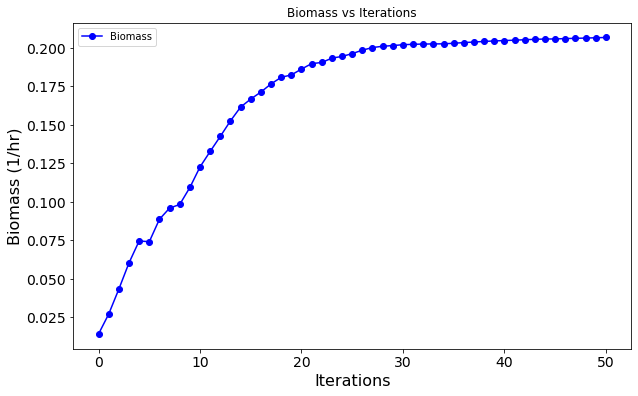

In [ ]:

print("=== Step 5: Running simulated annealing ===")
temperature = 1.0
cooling_rate = 0.95
min_temperature = 0.01
max_iterations = 100
max_unchanged_iterations = 4
change_threshold = 0.009
biomass_goal = 0.5

kcat_dict, top_targets, df_new, iterations, biomasses, df_FBA = simulated_annealing(
    model=irrev_model,
    processed_data=processed_data,
    biomass_reaction=biomass_reaction,
    objective_value=biomass_goal,
    gene_sequences_dict=gene_sequences_dict,      # ← new
    output_dir=tuning_results_dir,
    enzyme_fraction=enzyme_upper_bound,
    temperature=temperature,
    cooling_rate=cooling_rate,
    min_temperature=min_temperature,
    max_iterations=max_iterations,
    max_unchanged_iterations=max_unchanged_iterations,
    change_threshold=change_threshold
)

print(f"Final biomass: {biomasses[-1]:.4f}")
print(f"Improvement: {(biomasses[-1] - biomasses[0]) / biomasses[0] * 100:.1f}%")
print("Top 10 enzymes by mass contribution:")
print(top_targets[['Reactions','Single_gene','enzyme_mass']])


### Step 6: FVA 

In [ ]:

print("=== Step 6: Running Flux Variability Analysis ===")
fva_results_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_results.csv")
fva_plot_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_flux_range_plot.png")
fva_cumulative_path = os.path.join(tuning_results_dir, f"{organism_strain_GEMname}_fva_cumulative_plot.png")

fva_results, _, _ = flux_variability_analysis(
    model=irrev_model,
    processed_df=df_new,
    biomass_reaction=biomass_reaction,
    output_file=fva_results_path,
    enzyme_upper_bound=enzyme_upper_bound
)

# Plot standard FVA range
fig = plot_flux_variability(fva_results, output_file=fva_plot_path)

# Plot cumulative distribution
plot_cumulative_fvi_distribution(
    dfs=[fva_results],
    labels=[organism_strain_GEMname],
    output_file=fva_cumulative_path
)


=== Step 6: Running Flux Variability Analysis ===
=== Starting FVA with enzyme constraints ===
Model objective: Maximize
1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685
Optimal biomass: 0.206681
[1/2712] FVA for: ALATA_D2
Read LP format model from file C:\Users\Rana\AppData\Local\Temp\tmpufi5rf9h.lp


2025-06-18 21:46:00,914 - gurobipy - INFO - Read LP format model from file C:\Users\Rana\AppData\Local\Temp\tmpufi5rf9h.lp


Reading time = 0.02 seconds


2025-06-18 21:46:00,914 - gurobipy - INFO - Reading time = 0.02 seconds


: 1877 rows, 5424 columns, 21150 nonzeros


...

Reading time = 0.03 seconds


2025-06-19 15:13:09,794 - gurobipy - INFO - Reading time = 0.03 seconds


: 1877 rows, 5424 columns, 21150 nonzeros


2025-06-19 15:13:09,794 - gurobipy - INFO - : 1877 rows, 5424 columns, 21150 nonzeros


Model objective: Maximize
1.0*EX_ptrc_e - 1.0*EX_ptrc_e_reverse_6c850


### Step 7: Save Final Model

In [ ]:
# Define output path for final GEM
model_output_dir = os.path.join("models")
os.makedirs(model_output_dir, exist_ok=True)
model_output_path = os.path.join(model_output_dir, f"{run_id}.xml")

# After simulated annealing
model_with_kcats = assign_kcats_to_model(irrev_model, df_new)

# Preview:
format_kcats_like_gpr(model_with_kcats.reactions.get_by_id("PGI"))


# Save the final irreversible model
write_sbml_model(model_with_kcats, model_output_path)

print(f"Final GEM saved to: {model_output_path}")